# Statistical Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from scipy.stats import kruskal, chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Loading the data

In [2]:
df = pd.read_json("stats.json")

### Feature engineering

In [3]:
df["tempo_mean"] = df["tempos"].apply(np.mean)
df["tempo_std"] = df["tempos"].apply(np.std)
df["tempo_min"] = df["tempos"].apply(min)
df["tempo_max"] = df["tempos"].apply(max)
df["tempo_num_changes"] = df["tempos"].apply(len)
df["tempo_first"] = df["tempos"].apply(lambda x: x[0])
df["tempo_last"] = df["tempos"].apply(lambda x: x[-1])

In [4]:
df["ts_num_changes"] = df["time_signatures"].apply(len)
df["ts_unique"] = df["time_signatures"].apply(lambda x: len(set(x)))
df["ts_changes_flag"] = df["ts_num_changes"] > 1

In [5]:
df["durations_left_mean"] = df["durations_left"].apply(np.mean)
df["durations_right_mean"] = df["durations_right"].apply(np.mean)

### Loading target variable (difficulty)

In [6]:
import json

with open("splits.json", "r") as fp:
    splits = json.load(fp)

In [7]:
# extract label
difficulty_classifications = {}  # path: difficulty
for split in splits:
    test_ids = splits[split]["ids_test"]
    test_labels = splits[split]["y_test"]
    train_ids = splits[split]["ids_train"]
    train_labels = splits[split]["y_train"]
    for id, label in zip(test_ids, test_labels):
        # clean up name to match dataframe
        id = id.split("/")[-1]
        difficulty_classifications[id] = label
    for id, label in zip(train_ids, train_labels):
        id = id.split("/")[-1]
        difficulty_classifications[id] = label

In [8]:
# pair to df filename column
difficulty_classifications = pd.DataFrame(
    difficulty_classifications.items(), columns=["filename", "difficulty"]
)
df = df.merge(difficulty_classifications, on="filename")
df.head()

,durations_left,durations_right,distance_k_left,distance_k_right,key_signature,time_signatures,tempos,note_range_left,note_range_right,num_accidentals_left,...,tempo_max,tempo_num_changes,tempo_first,tempo_last,ts_num_changes,ts_unique,ts_changes_flag,durations_left_mean,durations_right_mean,difficulty
0,"[2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4]","[2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4]","[136.0039832245427, 111.12692703119274, 39.201...","[34.00099580613565, 27.781731757798184, 9.8003...",0,[4/4],[96],260.739741,65.184935,0,...,96,1,96,96,1,1,False,2.285714,2.285714,0
1,"[3, 3, 3, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 3, ...","[1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 3, 3, 1, 1, ...","[55.56346351559637, 62.367879068879404, 42.767...","[27.781731757798184, 31.183939534439673, 21.38...",-1,[3/4],[108],146.335232,73.167616,0,...,108,1,108,108,1,1,False,1.636364,1.500000,0
2,"[0.5, 0.5, 0.5, 0.5, 0.25, 0.25, 0.5, 0.75, 0....","[0.5, 0.5, 0.5, 0.5, 1, 1, 1.5, 0.5, 1, 0.5, 0...","[164.25574434325426, 83.25113060119736, 29.367...","[146.31320526564596, 33.94435274520879, 33.944...",-1,"[3/8, 5/8]",[152],490.326104,250.490919,16,...,152,1,152,152,2,2,True,0.584112,0.561905,1
3,"[0.5, 0.5, 0.5, 0.5, 1, 1, 0.5, 0.5, 0.5, 0.5,...","[2, 0.5, 0.5, 0.5, 0.5, 2, 0.5, 0.5, 0.5, 0.5,...","[41.62556530059862, 46.72311728934548, 73.6647...","[52.0888569289321, 29.43371949477674, 33.03823...",2,[2/4],[110],270.166044,355.291986,47,...,110,1,110,110,1,1,False,0.676923,0.731707,1
4,"[1, 1, 1.0, 1.0, 1.0, 1, 1, 1, 1, 2, 1, 0.5, 0...","[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, ...","[61.52638604178618, 584.4253535622287, 437.256...","[123.05277208357236, 123.05277208357236, 76.32...",2,"[3/4, 2/4]","[98, 134, 125, 110]",1220.511369,244.002282,81,...,134,4,98,110,2,2,True,0.762172,2.714286,1


### Data types

In [9]:
# target column to predict / find statistical relationships with
target = "difficulty"
# columns we don't care about, i.e. have already been engineered into something else
ignore = ["filename"]
ignore.extend(df.dtypes[df.dtypes == "object"].index.tolist())
# grab known categorical columns
categorical = [
    "key_signature",
    "tempo_num_changes",
    "ts_num_changes",
    "ts_unique",
    "ts_changes_flag",
]
# remaining columns are numerical
numerical = list(set(df.columns) - set([target]) - set(ignore) - set(categorical))

### EDA Graphing

In [10]:
def plot_categorical(category: str, ax):
    ct = pd.crosstab(df[category], df[target])
    sb.heatmap(data=ct, annot=True, ax=ax)
    ax.set_ylabel(category.title())
    ax.set_xlabel(target.title())
    ax.set_title(f"{target.title()} vs {category.title()}")


def plot_numerical(col: str, ax):
    sb.boxenplot(data=df, x=target, y=col, ax=ax)
    ax.set_ylabel(col.title())
    ax.set_xlabel(target.title())
    ax.set_title(f"{target.title()} vs {col.title()}")

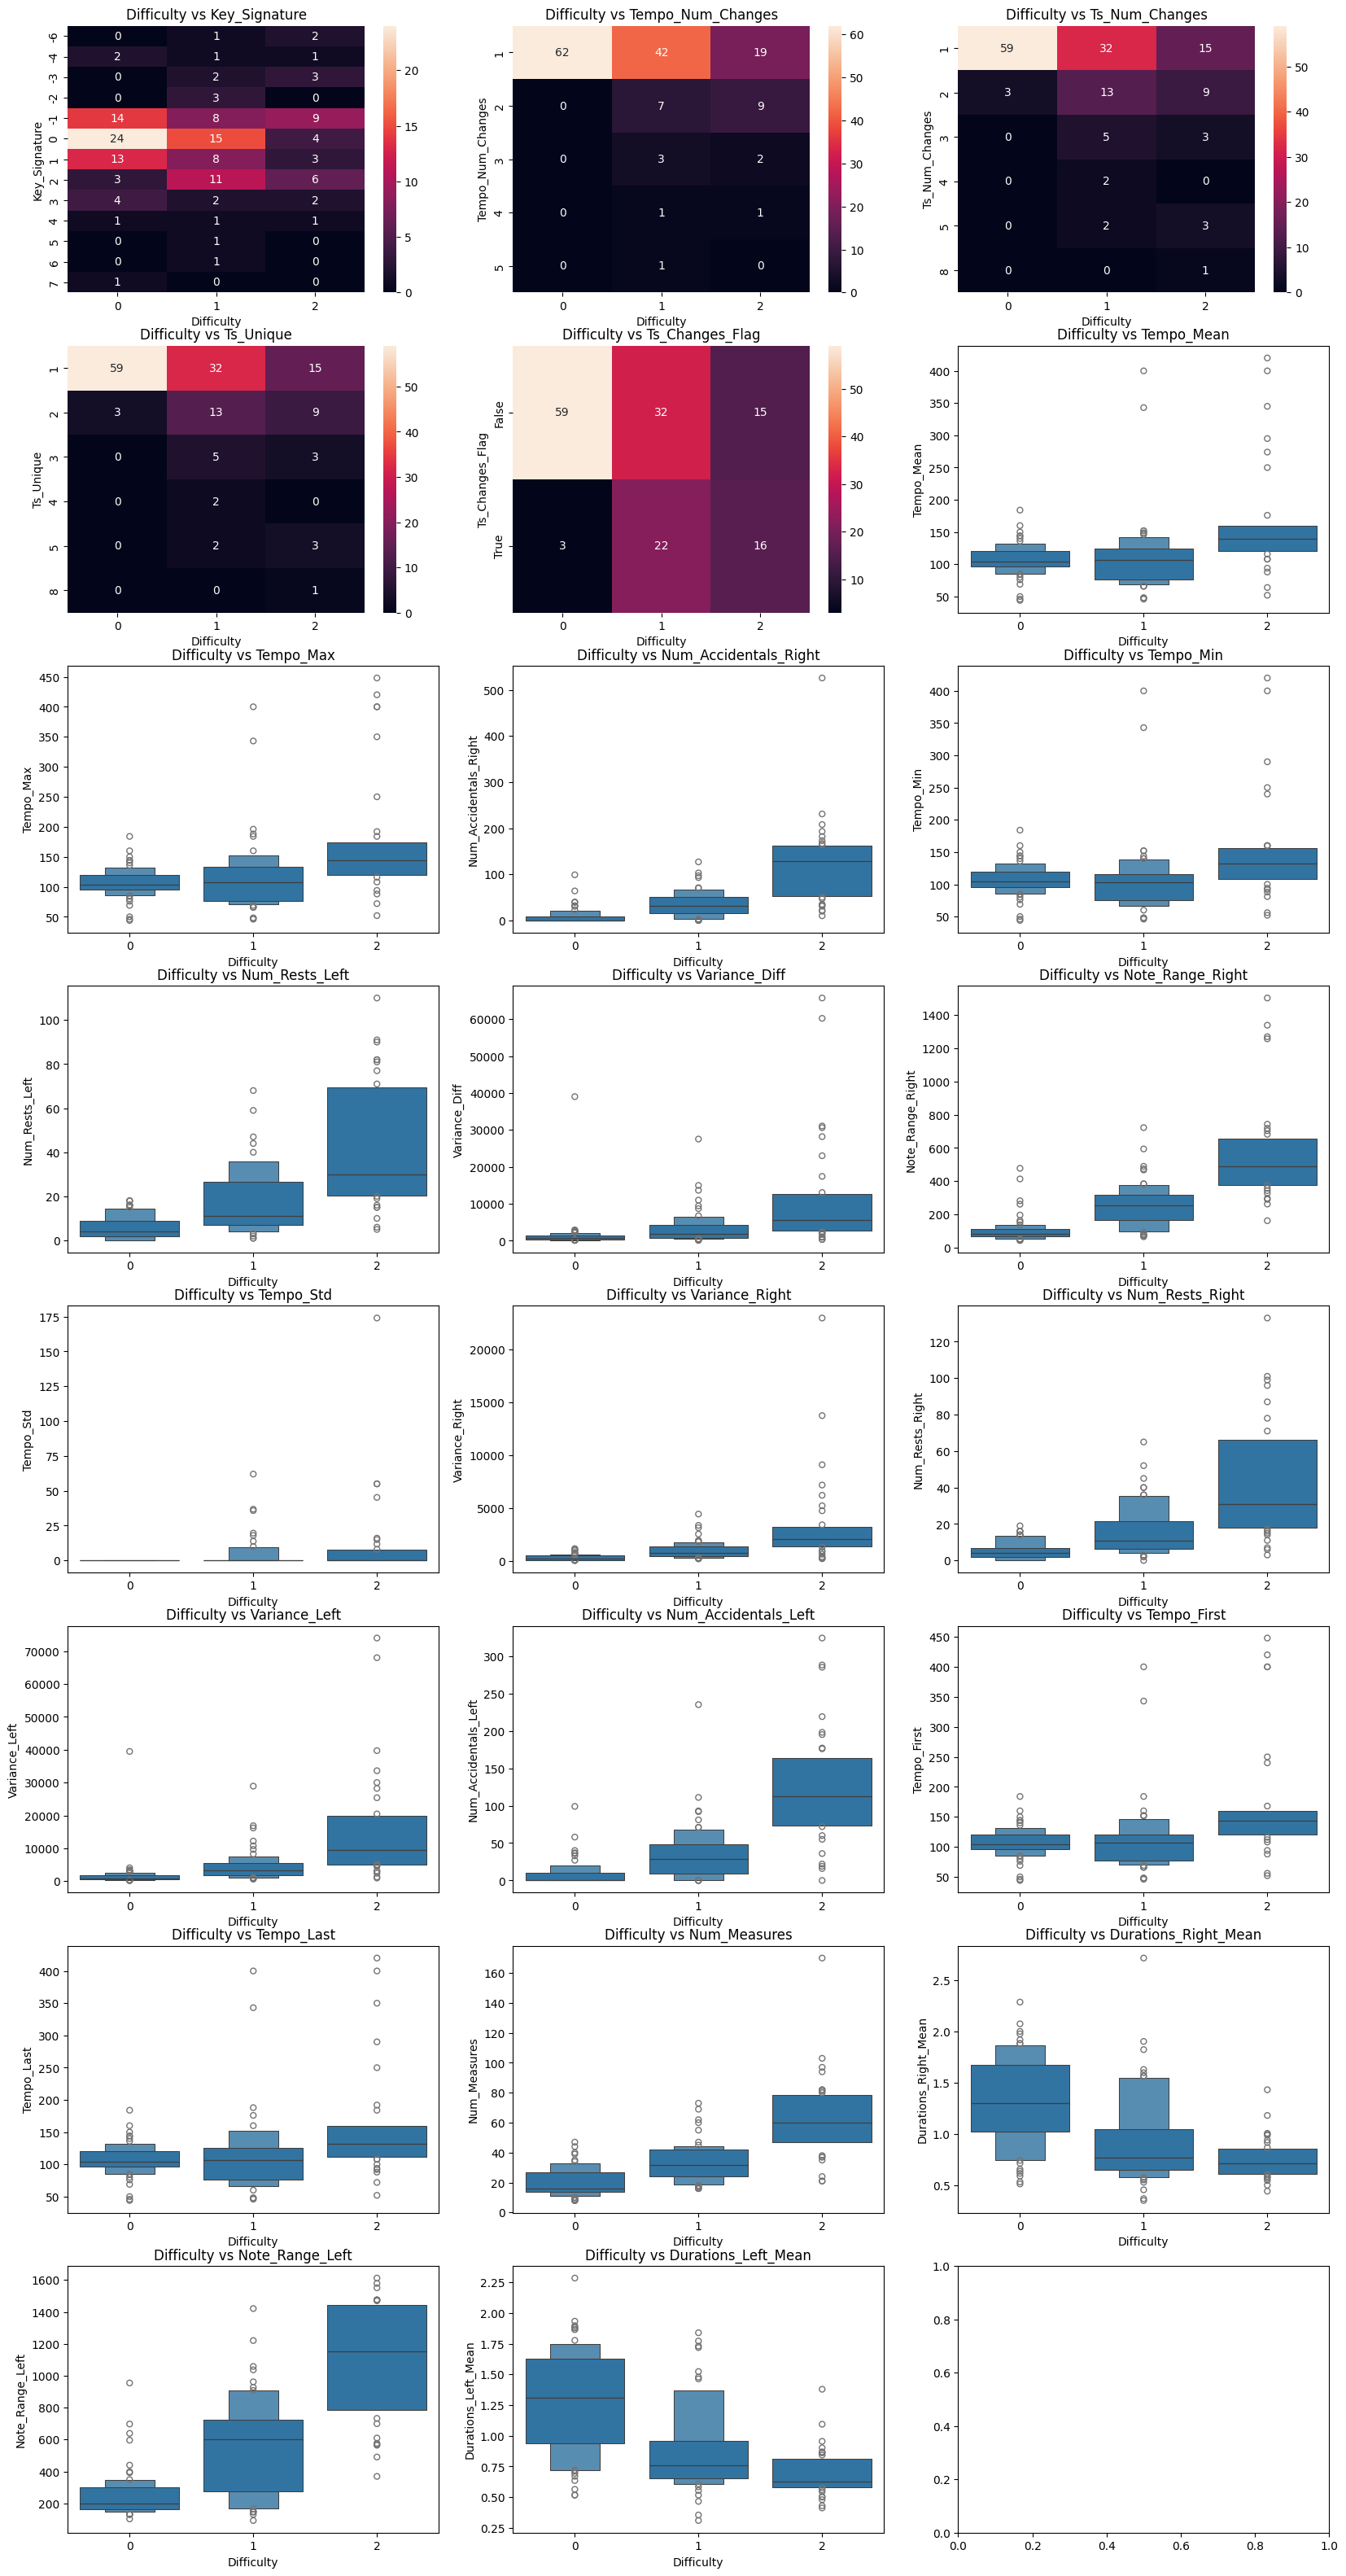

In [11]:
plots = [c for c in categorical] + [n for n in numerical]

n_plots = len(plots)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 40))
axes = axes.flatten()

i = 0

for c in categorical:
    plot_categorical(c, axes[i])
    i += 1

for n in numerical:
    plot_numerical(n, axes[i])
    i += 1

### Statistical analysis

In [12]:
num_tests = len(categorical) + len(numerical)
bonferroni = 0.05 / num_tests


def test_categorical(col: str):
    contingency = pd.crosstab(df[col], df[target])
    _, p_value, _, _ = chi2_contingency(contingency)
    return p_value < bonferroni


def test_numerical(col: str):
    groups = [df[df[target] == val][col] for val in df[target].unique()]
    _, p_value = kruskal(*groups)
    return p_value < bonferroni

In [13]:
predictive_features = []
for col in categorical:
    if col != "Name":
        is_significant = test_categorical(col)
        print(f"Column: {col}, is_significant: {is_significant}")
        if is_significant:
            predictive_features.append(col)
for col in numerical:
    if col != target:
        is_significant = test_numerical(col)
        print(f"Column: {col}, is_significant: {is_significant}")
        if is_significant:
            predictive_features.append(col)

Column: key_signature, is_significant: False
Column: tempo_num_changes, is_significant: True
Column: ts_num_changes, is_significant: True
Column: ts_unique, is_significant: True
Column: ts_changes_flag, is_significant: True
Column: tempo_mean, is_significant: True
Column: tempo_max, is_significant: True
Column: num_accidentals_right, is_significant: True
Column: tempo_min, is_significant: True
Column: num_rests_left, is_significant: True
Column: variance_diff, is_significant: True
Column: note_range_right, is_significant: True
Column: tempo_std, is_significant: True
Column: variance_right, is_significant: True
Column: num_rests_right, is_significant: True
Column: variance_left, is_significant: True
Column: num_accidentals_left, is_significant: True
Column: tempo_first, is_significant: True
Column: tempo_last, is_significant: True
Column: num_measures, is_significant: True
Column: durations_right_mean, is_significant: True
Column: note_range_left, is_significant: True
Column: durations_

### Predictive model

In [14]:
X = df[predictive_features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

In [15]:
knn = KNeighborsClassifier()

pipeline = Pipeline([("scaler", StandardScaler()), ("model", knn)])

cv = StratifiedKFold(n_splits=5, shuffle=True)
grid = GridSearchCV(
    pipeline,
    param_grid={
        "model__n_neighbors": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "model__weights": ["uniform", "distance"],
        "model__p": [1, 2],  # Manhattan vs Euclidean
    },
    scoring="accuracy",
    cv=cv,
)
grid.fit(X_train, y=y_train)

print(grid.best_params_)
print(grid.best_score_)

{'model__n_neighbors': 6, 'model__p': 1, 'model__weights': 'distance'}
0.761231884057971


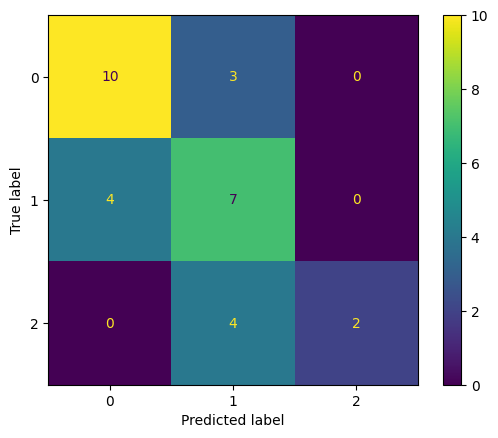

In [16]:
y_pred = grid.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()